In [1]:
import sys
import os
import time

from SelfCal import PipelineWrapper
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, \
load_calibration, make_spherex_offset_map, compute_offsets_guess, load_lvf_params, compute_vertical_strip_adjacency, \
make_stripped_chunk_map, make_stripped_chunk_valid_mask
from SelfCal.SPHERExAppendWav import wav_coadd

from astropy.io import fits
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
mpl.rcParams['figure.dpi'] = 200
# Import LogNorm
from tqdm import tqdm
import gc
from functools import partial


In [2]:
DETECTOR = 4
OVERSAMPLE_FACTOR = 2
NUM_SUBCHANNELS = 10
NUM_CHANNELS = 17
NUM_VERTICAL_BANDS = 5
FILE_SUFFIX = f'_vertical{NUM_VERTICAL_BANDS}bands'
FILE_PREFIX = f''

config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'SPHEREx_nep_qr2_det{DETECTOR}_6p2arcsec'
config['resolution_arcsec'] = 6.2


In [3]:
lvf_filename = f'lvf_params_D{DETECTOR}.npy'
lvf_params = load_lvf_params(lvf_filename)

Loaded LVF parameters from /home/thomasli/spherex/selfcal/selfcal_scripts/lvf_params/lvf_params_D4.npy


In [7]:
grid_chunk_map, _ = make_stripped_chunk_map(DETECTOR, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, num_vertical_bands=NUM_VERTICAL_BANDS,
                                                oversample_factor=OVERSAMPLE_FACTOR, lvf_params=lvf_params)
det_chunk_map, _ = make_stripped_chunk_map(DETECTOR, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, num_vertical_bands=NUM_VERTICAL_BANDS,
                                           oversample_factor=1, lvf_params=lvf_params)

Making chunk map...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:05<00:00, 33.92it/s]


Making chunk map...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:01<00:00, 138.36it/s]


In [9]:
ch = [12]

chunk_valid_mask_padded = make_stripped_chunk_valid_mask(ch, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                   num_vertical_bands=NUM_VERTICAL_BANDS, subchannel_padding=1)
chunk_valid_mask = make_stripped_chunk_valid_mask(ch, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                   num_vertical_bands=NUM_VERTICAL_BANDS, subchannel_padding=0)

adj_info = compute_vertical_strip_adjacency(det_chunk_map, NUM_VERTICAL_BANDS)

Computing Vertical Strip Adjacency (Filtering Arcs)...
Found 687 vertical strip boundaries.


In [14]:
det_chunk_map

array([[855, 855, 855, ..., 859, 859, 859],
       [855, 855, 855, ..., 859, 859, 859],
       [855, 855, 855, ..., 859, 859, 859],
       ...,
       [  5,   5,   5, ...,  14,  14,  14],
       [  5,   5,   5, ...,   9,  14,  14],
       [  5,   5,   5, ...,   9,   9,   9]],
      shape=(2040, 2040), dtype=int32)

In [17]:
len(np.unique(det_chunk_map))

860

In [ ]:
cc = PipelineWrapper.Calibrator(config)
cc.setup_lsqr(
    apply_mask=True, 
    apply_weight=False,
    chunk_map=det_chunk_map, 
    det_valid_mask=det_valid_mask_padded, 
    max_workers=50, 
    outlier_thresh=10.0,
    ignore_list=[],
    oversample_factor=1,#OVERSAMPLE_FACTOR,
    batch_size=30,
    reg_weight=1.0,
    adj_info=adj_info
    )

In [ ]:
cc.apply_lsqr(x0=None, atol=1e-06, btol=1e-06, damp=1e-3, iter_lim=100, precondition=False)

In [ ]:
cal_path = cc.save_calibration(cal_file=f'cal{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}{FILE_SUFFIX}.h5')
# cal_path = cc.save_calibration(cal_file=f'cal{FILE_PREFIX}_D{DETECTOR}{FILE_SUFFIX}.h5')

In [13]:
chunk_cube = np.array([det_chunk_map == i for i in tqdm(np.arange(np.max(det_chunk_map)+1))])
mean_offset_map = np.einsum('i,ijk->jk', cc.O.mean(axis=0), chunk_cube)

In [28]:
single_offset_map = np.einsum('i,ijk->jk', cc.O[100], chunk_cube)

In [152]:
from SelfCal.MapHelper import bin2d_cv

In [15]:
plt.imshow(np.where(det_valid_mask, single_offset_map, np.nan))
# plt.ylim(3000, 3500)
plt.colorbar()

In [28]:
mm = PipelineWrapper.Mosaicker(config)
mm.load_calibration('/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det1_6p2arcsec/calibration/cal_D1_Ch16_17channels_5verticalbands_weighteddamping.h5')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 13184/13184 [00:00<00:00, 585123.74it/s]


Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det1_6p2arcsec/calibration/cal_D1_Ch16_17channels_5verticalbands_weighteddamping.h5


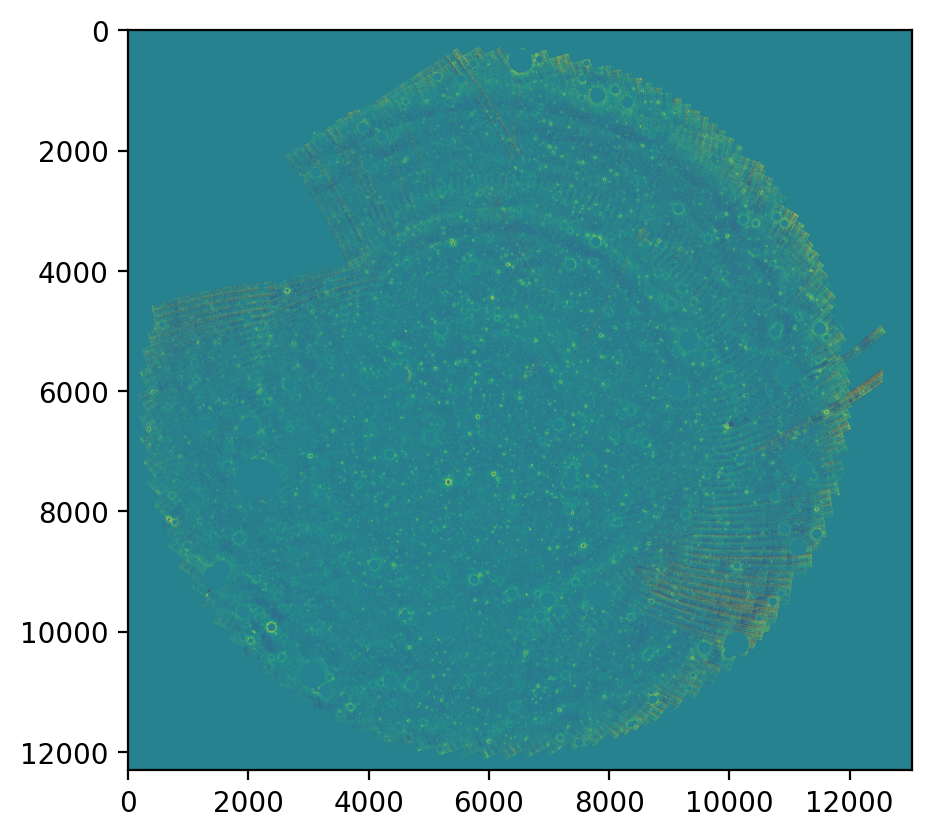

In [29]:
vmin, vmax = np.nanpercentile(mm.S[np.nonzero(mm.S)], [1, 99])
plt.imshow(mm.S, vmin=vmin, vmax=vmax)

In [24]:
# vmin, vmax = np.nanpercentile(cc.S[np.nonzero(cc.S)], [1, 99])
# plt.imshow(cc.S, vmin=vmin, vmax=vmax)

In [141]:
num_sky = np.prod(cc.ref_shape)

matrix = cc.A
n_cols = matrix.shape[1]
mask = np.ones(n_cols, dtype=bool)
mask[matrix.col] = False

target_mask = mask[num_sky + 1:]

empty_offsets_idx = np.where(target_mask)[0]

In [145]:
exp_idx = 4030
num_chunk = 860
offset_range = exp_idx * num_chunk, (exp_idx + 1) * num_chunk

In [146]:
offset_range

In [144]:
empty_offsets_idx%860

In [139]:
mask[num_sky:]

In [135]:
(84993612-num_sky)/4412

In [126]:
cc.O.shape

In [48]:
R = lvf_params['R']
xc, yc = lvf_params['xc'], lvf_params['yc']

edge_valid_mask = subchannel_valid_mask[1:].astype(bool) | subchannel_valid_mask[:-1].astype(bool)
edge_R = R[edge_valid_mask]

In [54]:
edge_x = np.linspace(0, 2040, NUM_VERTICAL_BANDS+1)

In [57]:
def mean_preserving_spline_2d(x_edges, y_edges, z_means, kx=3, ky=3):
    """
    Generates a mean-preserving spline function f(x, y) based on 2D grid edges
    and the average value z_mean in each rectangular cell.

    The function f(x, y) is constructed as the mixed partial derivative of a 
    bicubic spline F(x, y), where F(x, y) is the double integral of f(x, y).

    Parameters
    ----------
    x_edges : array_like, shape (N+1,)
        The edges of the bins along the x-axis.
    y_edges : array_like, shape (M+1,)
        The edges of the bins along the y-axis.
    z_means : array_like, shape (N, M)
        The mean value of the function within each rectangular bin.
    kx, ky : int, optional
        The degrees of the spline in x and y directions. Default is 3 (bicubic).
        
    Returns
    -------
    f_spline : callable
        A function f(x, y, grid=False) that evaluates the interpolated density.
        - If grid=True, evaluates on the grid spanned by x and y vectors.
        - If grid=False, evaluates at coordinates (x, y).
    """
    x_edges = np.asarray(x_edges, dtype=float)
    y_edges = np.asarray(y_edges, dtype=float)
    z_means = np.asarray(z_means, dtype=float)

    # 1. Validation
    if x_edges.shape[0] != z_means.shape[0] + 1:
        raise ValueError("len(x_edges) must be len(z_means) + 1 (rows)")
    if y_edges.shape[0] != z_means.shape[1] + 1:
        raise ValueError("len(y_edges) must be z_means.shape[1] + 1 (cols)")

    # 2. Compute Interval Areas (Volumes)
    # dx: (N,) -> column vector (N, 1)
    # dy: (M,) -> row vector (1, M)
    dx = np.diff(x_edges)
    dy = np.diff(y_edges)
    
    # Calculate volume of each cell: z_mean * dx * dy
    # Broadcasting: (N, 1) * (1, M) * (N, M)
    cell_volumes = z_means * dx[:, None] * dy[None, :]

    # 3. Compute Cumulative Integrals (2D Cumulative Sum)
    # The integral at (x0, y0) is 0.
    # The integral at (xi, yj) is sum of volumes in rect defined by [0:i, 0:j]
    integral_grid = np.zeros((len(x_edges), len(y_edges)))
    
    # cumsum over x (axis 0), then over y (axis 1)
    cumulative_volumes = np.cumsum(np.cumsum(cell_volumes, axis=0), axis=1)
    
    # Fill the integral grid (row 0 and col 0 remain 0s)
    integral_grid[1:, 1:] = cumulative_volumes

    # 4. Interpolate the Integral Surface F(x, y)
    # RectBivariateSpline creates a smooth surface over the regular grid
    F_spline = RectBivariateSpline(x_edges, y_edges, integral_grid, kx=kx, ky=ky)

    # 5. Define the Density Function
    # f(x, y) = d^2 F / dx dy
    # RectBivariateSpline allows calculating partial derivatives directly.
    
    def f_spline(x, y, grid=False):
        """
        Evaluate the mean-preserving spline.
        grid=True: x and y are vectors defining a grid.
        grid=False: x and y are coordinates of points.
        """
        # Calculate mixed partial derivative (dx=1, dy=1)
        return F_spline(x, y, dx=1, dy=1, grid=grid)

    return f_spline

In [20]:
cal_path = '/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/calibration/cal_D4_Ch12_17channels_5verticalbands.h5'
mm = PipelineWrapper.Mosaicker(config)
mm.load_calibration(cal_path=cal_path)
# partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)
sc_sigma = 1.0
maps = mm.make_mosaic(
    apply_mask=True, 
    apply_weight=False, 
    chunk_map=grid_chunk_map, 
    det_valid_mask=grid_valid_mask, 
    max_workers=20,
    make_std_map=True, 
    apply_sigma_clipping=True,  
    sigma=sc_sigma,
    ignore_list=[21],
    oversample_factor=OVERSAMPLE_FACTOR,
    det_offset_func=None,#partial_make_offset_map,
    cache_batch_size=20,
    coadd_batch_size=100,
    cache_dir='/home/thomasli/spherex/selfcal/cache',
    cache_intermediate=True,
    det_aux=None
)

    # wav_mean, wav_std = wav_coadd(det_BC, det_BW, mean_map=maps['mean_map']['data'], std_map=maps['std_map']['data'], 
    #                               reproj_list=mm.reproj_list, cache_list=mm.cached_list, ref_shape=maps['mean_map']['data'].shape, 
    #                               sigma=sc_sigma, batch_size=40, max_workers=40)    

    # wav_mean_maps = {'data': wav_mean, 'unit': 'um'}
    # wav_std_maps = {'data': wav_std, 'unit': 'um'}
    # mm.append_maps({'wav_mean_map': wav_mean_maps, 'wav_std_map': wav_std_maps})

mm.save_mosaic(mos_file=f'mosaic{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}{FILE_SUFFIX}.fits', overwrite=True)

    # # Clear memory
    # del mm, maps
    # gc.collect()
    # t1 = time.time()
    # print(f"Finished channel {ch} for detector {DETECTOR} in {t1 - t0:.2f} seconds")


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 13184/13184 [00:00<00:00, 1424354.22it/s]


Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/calibration/cal_D4_Ch12_17channels_5verticalbands.h5
Caching intermediate computations...
Processing 13184 files in 660 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 660/660 [23:22<00:00,  2.12s/it]

Cache computation finished in 1403.28 seconds.
Computing mean map...
Processing 13184 files in 132 batches...



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [07:24<00:00,  3.37s/it]


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [07:29<00:00,  3.40s/it]


Std map computation finished in 451.74 seconds.
Computing sigma-clipped mean map...
Processing 13184 files in 132 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [08:51<00:00,  4.03s/it]


Sigma-clipped mean map computation finished in 535.50 seconds.
Mosaic saved to /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/mosaic/mosaic_D4_Ch12_vertical5bands.fits


'/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/mosaic/mosaic_D4_Ch12_vertical5bands.fits'

In [21]:
mosaic = mm.maps['mean_map']['data']

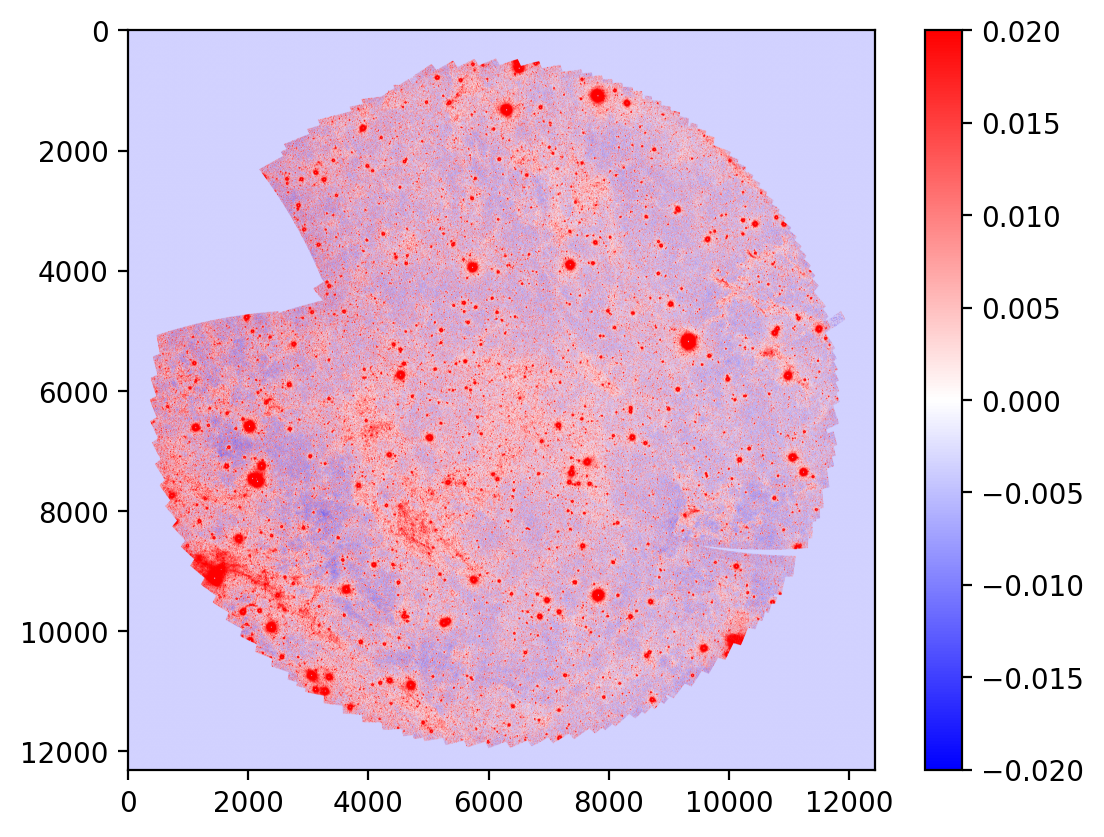

In [22]:
plt.imshow(mosaic-np.nanmedian(mosaic[np.nonzero(mosaic)]), vmin=-0.02, vmax=0.02, cmap='bwr')
plt.colorbar()

In [147]:
OO = cc.O[:,chunk_valid_mask.astype(bool)].reshape(4412, 12, 5)

In [148]:
plt.plot(OO[4030].T)

In [21]:
vmin, vmax = np.percentile(mosaic[np.nonzero(mosaic)], [1, 99])+0.02
plt.imshow(mosaic+0.02, norm=LogNorm(vmin=vmin, vmax=vmax))
plt.colorbar()